# HDB Resale Price Regression — Notebook 1: Download and Prepare Data

What predicts HDB resale prices in Singapore? This notebook pulls all five HDB resale datasets from data.gov.sg (~975K transactions from 1990 to present), harmonises the schemas, derives the variables I need for regression, and saves two outputs: the full historical dataset and a 2-year slice for regression.

## Setup Python and R environment

In [1]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

Error importing in API mode: ImportError("dlopen(/Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


In [2]:
%%R

require('tidyverse')
require('scales')

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: tidyverse
Loading required package: scales

Attaching package: ‘scales’

The following object is masked from ‘package:purrr’:

    discard

The following object is masked from ‘package:readr’:

    col_factor



## Load and merge all 5 datasets

The five datasets have slightly different schemas:

| Dataset | Period | Basis | `remaining_lease` | Storey bands |
|---|---|---|---|---|
| 1990–1999 | Jan 1990 – Dec 1999 | Approval date | No | 3-floor |
| 2000–2012 | Jan 2000 – Feb 2012 | Approval date | No | 3-floor |
| 2012–2014 | Mar 2012 – Dec 2014 | Registration date | No | 5-floor |
| 2015–2016 | Jan 2015 – Dec 2016 | Registration date | Yes (years only) | 3-floor |
| 2017–present | Jan 2017 – present | Registration date | Yes (years + months) | 3-floor |

I derive `remaining_lease_years` from `lease_commence_date` for all rows, so the missing `remaining_lease` column pre-2015 doesn't matter. The 2012–2014 dataset uses wider 5-floor storey bands, making `storey_mid` less precise for that era. Date basis switched from approval to registration in Mar 2012.

In [3]:
import glob

# Load all 5 datasets
files = {
    'data/hdb_resale_1990_1999.csv': '1990-1999',
    'data/hdb_resale_2000_2012.csv': '2000-2012',
    'data/hdb_resale_2012_2014.csv': '2012-2014',
    'data/hdb_resale_2015_2016.csv': '2015-2016',
    'data/hdb_resale_2017_present.csv': '2017-present',
}

# Common columns across all datasets
common_cols = ['month', 'town', 'flat_type', 'block', 'street_name',
               'storey_range', 'floor_area_sqm', 'flat_model',
               'lease_commence_date', 'resale_price']

dfs = []
for filepath, label in files.items():
    try:
        raw = pd.read_csv(filepath, encoding='utf-8')
        # Keep only common columns (some datasets have remaining_lease, some don't)
        cols_to_keep = [c for c in common_cols if c in raw.columns]
        chunk = raw[cols_to_keep].copy()
        # Also keep remaining_lease if it exists
        if 'remaining_lease' in raw.columns:
            chunk['remaining_lease'] = raw['remaining_lease']
        chunk['dataset'] = label
        dfs.append(chunk)
        print(f"  {label}: {len(chunk):,} rows, columns: {chunk.columns.tolist()}")
    except FileNotFoundError:
        print(f"  {label}: FILE NOT FOUND — {filepath}")

df = pd.concat(dfs, ignore_index=True)
print(f"\n=== Combined: {len(df):,} total rows ===")

  1990-1999: 287,196 rows, columns: ['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'resale_price', 'dataset']


  2000-2012: 369,651 rows, columns: ['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'resale_price', 'dataset']
  2012-2014: 52,203 rows, columns: ['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'resale_price', 'dataset']
  2015-2016: 37,153 rows, columns: ['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'resale_price', 'remaining_lease', 'dataset']


  2017-present: 229,028 rows, columns: ['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'resale_price', 'remaining_lease', 'dataset']

=== Combined: 975,231 total rows ===


## Inspect raw data

In [4]:
print("=== Column names ===")
print(df.columns.tolist())

print("\n=== Data types ===")
print(df.dtypes)

print("\n=== Null counts ===")
print(df.isnull().sum())

print(f"\n=== Shape: {df.shape[0]:,} rows x {df.shape[1]} columns ===")

print(f"\n=== Date range ===")
print(f"Earliest month: {df['month'].min()}")
print(f"Latest month:   {df['month'].max()}")
print(f"Number of unique months: {df['month'].nunique()}")

=== Column names ===
['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'resale_price', 'dataset', 'remaining_lease']

=== Data types ===
month                   object
town                    object
flat_type               object
block                   object
street_name             object
storey_range            object
floor_area_sqm         float64
flat_model              object
lease_commence_date      int64
resale_price           float64
dataset                 object
remaining_lease         object
dtype: object

=== Null counts ===


month                       0
town                        0
flat_type                   0
block                       0
street_name                 0
storey_range                0
floor_area_sqm              0
flat_model                  0
lease_commence_date         0
resale_price                0
dataset                     0
remaining_lease        709050
dtype: int64

=== Shape: 975,231 rows x 12 columns ===

=== Date range ===
Earliest month: 1990-01
Latest month:   2026-04
Number of unique months: 436


## Filter to last 2 years

I keep only the most recent 24 months. A single regression across 35 years of data would average over fundamentally different markets — the 1997 crash, 2013 cooling measures, PM Lee's 2017 lease-decay speech, 2022 cooling measures — and the coefficients would describe no actual period. Nominal price inflation alone (a 4-room flat at ~$120K in 1995 vs ~$600K today) would dominate. A 2-year window gives ~50K transactions, enough for robust regression while keeping coefficients interpretable as today's market.

Rows with missing key fields are dropped, though in practice this dataset has none.

In [5]:
# Parse numeric columns
df['resale_price'] = pd.to_numeric(df['resale_price'], errors='coerce')
df['floor_area_sqm'] = pd.to_numeric(df['floor_area_sqm'], errors='coerce')
df['lease_commence_date'] = pd.to_numeric(df['lease_commence_date'], errors='coerce')

# Parse month as datetime
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')

# Drop rows with missing key fields
key_fields = ['resale_price', 'floor_area_sqm', 'lease_commence_date', 'storey_range', 'town', 'flat_type']
before = len(df)
df = df.dropna(subset=key_fields)
after = len(df)
print(f"Dropped {before - after} rows with missing key fields ({before:,} -> {after:,})")

print(f"\n=== Full dataset ===")
print(f"Date range: {df['month'].min().strftime('%Y-%m')} to {df['month'].max().strftime('%Y-%m')}")
print(f"Rows: {len(df):,}")

# We keep the FULL dataset for now — derive variables on everything,
# then split into full (trend analysis) and 2-year (regression) at save time.

Dropped 0 rows with missing key fields (975,231 -> 975,231)



=== Full dataset ===
Date range: 1990-01 to 2026-04
Rows: 975,231


## Derive variables

- **`storey_mid`**: Midpoint of the storey range (e.g. "07 TO 09" becomes 8). Loses some granularity but gives us a numeric predictor for floor height.

- **`remaining_lease_years`**: `99 - (transaction_year - lease_commence_date)`. Key predictor — lease decay accelerates as leases shorten, so a flat with 50 years left is worth disproportionately less than one with 90.

- **`log_resale_price`**: `log10(resale_price)` for EDA histograms only. Y variable for regression is raw `resale_price` in dollars — the range (~$150K to ~$1.7M) isn't wide enough to need log, and raw-dollar coefficients make better copy. We use robust standard errors to handle the larger variance at the top end.

- **`ends_in_8`**: Whether the last digit of the resale price is 8.

- **`last_digit`**: The ones digit. We check all 10 to see if 0 and 8 are overrepresented.

In [6]:
# Derive storey_mid from storey_range
# Format is like "07 TO 09" -> extract low and high, take midpoint
df['storey_low'] = df['storey_range'].str.extract(r'(\d+)\s+TO').astype(float)
df['storey_high'] = df['storey_range'].str.extract(r'TO\s+(\d+)').astype(float)
df['storey_mid'] = (df['storey_low'] + df['storey_high']) / 2

print("storey_range -> storey_mid examples:")
print(df[['storey_range', 'storey_low', 'storey_high', 'storey_mid']].drop_duplicates().sort_values('storey_mid').head(10))

# Clean up temp columns
df = df.drop(columns=['storey_low', 'storey_high'])

storey_range -> storey_mid examples:
       storey_range  storey_low  storey_high  storey_mid
5          01 TO 03         1.0          3.0         2.0
656848     01 TO 05         1.0          5.0         3.0
1          04 TO 06         4.0          6.0         5.0
3          07 TO 09         7.0          9.0         8.0
656847     06 TO 10         6.0         10.0         8.0
0          10 TO 12        10.0         12.0        11.0
656855     11 TO 15        11.0         15.0        13.0
37         13 TO 15        13.0         15.0        14.0
144        16 TO 18        16.0         18.0        17.0
656874     16 TO 20        16.0         20.0        18.0


In [7]:
# Derive remaining_lease_years
# All HDB flats have a 99-year lease from lease_commence_date
df['transaction_year'] = df['month'].dt.year
df['remaining_lease_years'] = 99 - (df['transaction_year'] - df['lease_commence_date'])

print("remaining_lease_years summary:")
print(df['remaining_lease_years'].describe())

# Check for bad values
bad = df[(df['remaining_lease_years'] < 0) | (df['remaining_lease_years'] > 99)]
if len(bad) > 0:
    print(f"\nWARNING: {len(bad)} rows with remaining_lease_years outside [0, 99]:")
    print(bad[['month', 'town', 'lease_commence_date', 'remaining_lease_years']].head())
else:
    print("\nAll remaining_lease_years values are within [0, 99]. Good.")

# Clean up temp column
df = df.drop(columns=['transaction_year'])

remaining_lease_years summary:
count    975231.000000
mean         80.684148
std          11.139349
min          39.000000
25%          74.000000
50%          83.000000
75%          90.000000
max         101.000000
Name: remaining_lease_years, dtype: float64

           month           town  lease_commence_date  remaining_lease_years
23271 1991-11-01         BISHAN                 1992                    100
34246 1992-08-01       TAMPINES                 1993                    100
46535 1993-06-01      WOODLANDS                 1994                    100
69033 1994-05-01  CHOA CHU KANG                 1995                    100
69609 1994-05-01      PASIR RIS                 1995                    100


In [8]:
# Derive log_resale_price (kept for EDA histograms; Y for regression is raw resale_price)
df['log_resale_price'] = np.log10(df['resale_price'])

print("log_resale_price summary (for EDA reference):")
print(df['log_resale_price'].describe())
print(f"\nFor reference: log10(300,000) = {np.log10(300000):.4f}, log10(1,000,000) = {np.log10(1000000):.4f}")

log_resale_price summary (for EDA reference):
count    975231.000000
mean          5.454250
std           0.271645
min           3.698970
25%           5.301030
50%           5.488551
75%           5.638489
max           6.230449
Name: log_resale_price, dtype: float64

For reference: log10(300,000) = 5.4771, log10(1,000,000) = 6.0000


In [9]:
# Derive ends_in_8 and last_digit
df['last_digit'] = (df['resale_price'].astype(int) % 10).astype(int)
df['ends_in_8'] = (df['last_digit'] == 8).astype(int)

print(f"Transactions ending in 8: {df['ends_in_8'].sum():,} ({df['ends_in_8'].mean()*100:.1f}%)")
print(f"\nIf digits were uniformly distributed, we'd expect ~10%. Full distribution:\n")

# Full last-digit distribution
digit_counts = df['last_digit'].value_counts().sort_index()
print(digit_counts)
print(f"\nTotal: {digit_counts.sum():,}")

Transactions ending in 8: 21,199 (2.2%)

If digits were uniformly distributed, we'd expect ~10%. Full distribution:

last_digit
0    952893
1       151
2        55
3       130
4        29
5        87
6       138
7        79
8     21199
9       470
Name: count, dtype: int64

Total: 975,231


### Last-digit distribution

All 10 digits plotted. Dashed line = expected count if each digit appeared equally often (10%).

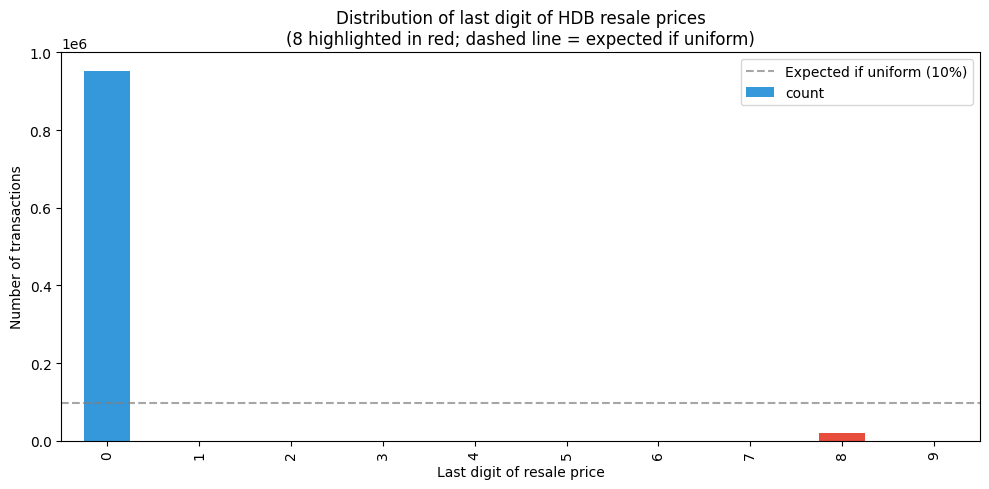

In [10]:
digit_counts = df['last_digit'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
digit_counts.plot(kind='bar', ax=ax, color=['#e74c3c' if d == 8 else '#3498db' for d in digit_counts.index])
ax.set_xlabel('Last digit of resale price')
ax.set_ylabel('Number of transactions')
ax.set_title('Distribution of last digit of HDB resale prices\n(8 highlighted in red; dashed line = expected if uniform)')
ax.axhline(y=len(df)/10, color='gray', linestyle='--', alpha=0.7, label='Expected if uniform (10%)')
ax.legend()
plt.tight_layout()
plt.show()

## 10 most and least expensive transactions

In [11]:
display_cols = ['month', 'town', 'block', 'street_name', 'flat_type', 'floor_area_sqm',
                'storey_range', 'resale_price', 'remaining_lease_years']

print("=== 10 MOST EXPENSIVE transactions ===")
display(df.nlargest(10, 'resale_price')[display_cols])

print("\n=== 10 CHEAPEST transactions ===")
display(df.nsmallest(10, 'resale_price')[display_cols])

=== 10 MOST EXPENSIVE transactions ===


,month,town,block,street_name,flat_type,floor_area_sqm,storey_range,resale_price,remaining_lease_years
972562,2026-02-01,QUEENSTOWN,92,DAWSON RD,5 ROOM,122.0,19 TO 21,1700000.0,89
958277,2025-06-01,QUEENSTOWN,92,DAWSON RD,5 ROOM,122.0,22 TO 24,1658888.0,90
969582,2026-03-01,BUKIT MERAH,9A,BOON TIONG RD,5 ROOM,112.0,25 TO 27,1648888.0,89
945679,2025-11-01,BISHAN,275A,BISHAN ST 24,5 ROOM,120.0,34 TO 36,1632000.0,85
945701,2025-11-01,BISHAN,135,BISHAN ST 12,EXECUTIVE,163.0,22 TO 24,1600000.0,61
948988,2025-08-01,CENTRAL AREA,1G,CANTONMENT RD,5 ROOM,105.0,49 TO 51,1600000.0,85
964679,2025-01-01,TOA PAYOH,138A,LOR 1A TOA PAYOH,5 ROOM,117.0,19 TO 21,1600000.0,86
948989,2025-09-01,CENTRAL AREA,1A,CANTONMENT RD,5 ROOM,107.0,40 TO 42,1590000.0,85
920374,2024-06-01,BUKIT MERAH,9B,BOON TIONG RD,5 ROOM,112.0,34 TO 36,1588000.0,91
920375,2024-06-01,BUKIT MERAH,96A,HENDERSON RD,5 ROOM,113.0,46 TO 48,1588000.0,94



=== 10 CHEAPEST transactions ===


,month,town,block,street_name,flat_type,floor_area_sqm,storey_range,resale_price,remaining_lease_years
6644,1990-07-01,BUKIT MERAH,7,TELOK BLANGAH CRES,1 ROOM,31.0,01 TO 03,5000.0,84
2440,1990-03-01,ANG MO KIO,309,ANG MO KIO AVE 1,1 ROOM,31.0,01 TO 03,5600.0,86
19376,1991-08-01,ANG MO KIO,309,ANG MO KIO AVE 1,1 ROOM,31.0,01 TO 03,5700.0,85
9585,1990-10-01,ANG MO KIO,309,ANG MO KIO AVE 1,1 ROOM,31.0,10 TO 12,5800.0,86
1,1990-01-01,ANG MO KIO,309,ANG MO KIO AVE 1,1 ROOM,31.0,04 TO 06,6000.0,86
3,1990-01-01,ANG MO KIO,309,ANG MO KIO AVE 1,1 ROOM,31.0,07 TO 09,6000.0,86
4851,1990-05-01,BUKIT MERAH,33,TAMAN HO SWEE,1 ROOM,29.0,10 TO 12,6000.0,78
11486,1990-12-01,ANG MO KIO,309,ANG MO KIO AVE 1,1 ROOM,31.0,01 TO 03,6000.0,86
12505,1991-01-01,ANG MO KIO,309,ANG MO KIO AVE 1,1 ROOM,31.0,01 TO 03,6000.0,85
22928,1991-11-01,ANG MO KIO,309,ANG MO KIO AVE 1,1 ROOM,31.0,01 TO 03,6700.0,85


## Save: full dataset and 2-year regression dataset

In [12]:
save_cols = [
    'month', 'town', 'block', 'street_name', 'resale_price', 'log_resale_price',
    'flat_type', 'flat_model', 'floor_area_sqm', 'storey_range', 'storey_mid',
    'lease_commence_date', 'remaining_lease_years',
    'ends_in_8', 'last_digit', 'dataset'
]

# Also keep remaining_lease if it exists
if 'remaining_lease' in df.columns:
    save_cols.insert(save_cols.index('ends_in_8'), 'remaining_lease')

available_cols = [c for c in save_cols if c in df.columns]
df_full = df[available_cols].copy()

# --- Save 1: Full historical dataset (1990–present) ---
df_full.to_csv('data/hdb_resale_full.csv', index=False)
print(f"=== FULL DATASET ===")
print(f"Saved to data/hdb_resale_full.csv ({len(df_full):,} rows, {len(available_cols)} cols)")
print(f"Date range: {df['month'].min().strftime('%Y-%m')} to {df['month'].max().strftime('%Y-%m')}")

# --- Save 2: Last 2 years only (for regression) ---
max_month = df['month'].max()
cutoff = max_month - pd.DateOffset(years=2)
df_recent = df_full[pd.to_datetime(df_full['month']) > cutoff].copy()
df_recent.to_csv('data/hdb_resale_cleaned.csv', index=False)
print(f"\n=== 2-YEAR REGRESSION DATASET ===")
print(f"Saved to data/hdb_resale_cleaned.csv ({len(df_recent):,} rows)")
print(f"Date range: {df_recent['month'].min()} to {df_recent['month'].max()}")

# Null check on both
for label, d in [('Full', df_full), ('2-year', df_recent)]:
    nulls = d.isnull().sum()
    has_nulls = nulls[nulls > 0]
    if len(has_nulls) > 0:
        print(f"\n{label} nulls: {has_nulls.to_dict()}")
    else:
        print(f"\n{label}: no nulls.")

=== FULL DATASET ===
Saved to data/hdb_resale_full.csv (975,231 rows, 17 cols)
Date range: 1990-01 to 2026-04

=== 2-YEAR REGRESSION DATASET ===
Saved to data/hdb_resale_cleaned.csv (50,718 rows)
Date range: 2024-05-01 00:00:00 to 2026-04-01 00:00:00



Full nulls: {'remaining_lease': 709050}

2-year: no nulls.


## Known limitations

- **Two-year window is arbitrary.** Sensitivity check with 12 or 36 months would be useful.
- **No geocoding.** `town` and `street_name` but no lat/lon — distance to MRT, CBD, schools needs supplementary data (Notebook 3).
- **Lease decay is linear here.** We add a quadratic term in Notebook 6 (Model 9) to capture the non-linear penalty at shorter leases.
- **No inflation adjustment.** Prices are nominal. Singapore inflation has been 3-4% annually over this period.
- **`ends_in_8` captures real pricing behaviour.** The share of 8-ending transactions has surged from near-zero in the 1990s to 8-10% recently. The coefficient measures the price premium *associated with* choosing an 8-ending price, not the "effect of" the number 8 — it reflects seller psychology, negotiation dynamics, and marketing strategy.
- **Transaction vs. listing price.** These are completed resale transactions, not listing prices. No data on failed negotiations or the asking-to-final gap.